In [1]:
import os, glob, re, html, copy, random, time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, Dataset
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_cosine_schedule_with_warmup
from torch.optim import AdamW

# --- Import LoRA from PEFT ---
from peft import LoraConfig, get_peft_model, TaskType

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1" 

# ==========================================
# 0. Configuration and Random Seed Setup
# ==========================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed set to {seed}")

set_seed(42)

EVENT_WISE_DIR = '/kaggle/input/datasets/jieyang02/aa-nlp/aa - nlp/HumAID_data_event_wise'
EVENT_TYPE_DIR = '/kaggle/input/datasets/jieyang02/aa-nlp/aa - nlp/HumAID_data_event_type/event_type'

MODEL_NAME = 'distilbert-base-uncased'
BATCH_SIZE = 16 
ACCUMULATION_STEPS = 2   # Gradient accumulation, equivalent to real Batch Size = 16 * 2 = 32
MAX_LEN = 128
EPOCHS = 5               # LoRA converges slightly slower, so 5 epochs are sufficient with EarlyStopping
PATIENCE = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Random seed set to 42


In [2]:
# ==========================================
# 1. Data Cleaning and DataLoaders
# ==========================================
def clean_tweet(text):
    if pd.isna(text): return ""
    text = html.unescape(str(text)).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+', '', text)
    
    # Disaster keyword de-biasing: Forces the model to learn contextual semantics 
    # rather than memorizing domain-specific disaster nouns
    disaster_keywords = ['earthquake', 'quake', 'fire', 'wildfire', 'flood', 'flooding', 'hurricane', 'storm', 'cyclone', 'typhoon']
    for kw in disaster_keywords:
        text = text.replace(kw, ' disaster ')
        
    text = text.replace('#', '')
    text = re.sub(r'(.)\1+', r'\1\1', text) 
    return " ".join(text.split())

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self): 
        return len(self.texts)
    
    def __getitem__(self, i):
        enc = self.tokenizer(
            str(self.texts[i]),
            add_special_tokens=True, 
            max_length=self.max_len, 
            padding='max_length',
            truncation=True, 
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(), 
            'labels': torch.tensor(self.labels[i], dtype=torch.long)
        }

class EarlyStoppingF1:
    def __init__(self, patience=2):
        self.patience = patience
        self.counter = 0
        self.best_f1 = -1.0
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, current_f1, model):
        if current_f1 > self.best_f1:
            self.best_f1 = current_f1
            # Save state dict to CPU memory to prevent GPU VRAM leakage across loops
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            print(f"     --> [Best F1: {self.best_f1:.4f}] Weights Saved.")
        else:
            self.counter += 1
            if self.counter >= self.patience: 
                self.early_stop = True

In [3]:
# ==========================================
# 2. Build Data Dictionary and Labels
# ==========================================
print("\nBuilding Dictionary...")
tweet_text_dict = {}
for file_path in glob.glob(os.path.join(EVENT_WISE_DIR, '**/*.tsv'), recursive=True):
    if os.path.basename(file_path).startswith('._'): continue
    try:
        df_temp = pd.read_csv(file_path, sep='\t', dtype={'tweet_id': str})
        for _, row in df_temp.iterrows():
            if pd.notna(row['tweet_id']):
                tweet_text_dict[str(row['tweet_id'])] = clean_tweet(row['tweet_text'])
    except: pass

ALL_TYPES = ['earthquake', 'fire', 'flood', 'hurricane']
data_dict = {t: {'train': None, 'dev': None, 'test': None} for t in ALL_TYPES}

def load_split(d, s):
    path = os.path.join(EVENT_TYPE_DIR, f'{d}_{s}.tsv')
    if not os.path.exists(path): return pd.DataFrame()
    df = pd.read_csv(path, sep='\t', dtype={'tweet_id': str})
    df['tweet_text'] = df['tweet_id'].map(tweet_text_dict)
    return df.dropna(subset=['tweet_text', 'class_label'])

all_labels = []
for d in ALL_TYPES:
    for s in ['train', 'dev', 'test']:
        df = load_split(d, s)
        data_dict[d][s] = df
        if not df.empty: 
            all_labels.extend(df['class_label'].tolist())

# Global Label Encoder (11-Class Configuration)
label_encoder = LabelEncoder().fit(all_labels)
num_labels = len(label_encoder.classes_)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Building Dictionary...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
# ==========================================
# 3. Leave-One-Type-Out (LOTO) Cross-Validation
# ==========================================
results = []
print("\n" + "="*80)
print("STARTING LEAVE-ONE-TYPE-OUT (LOTO) EXPERIMENT WITH DistilBERT + LoRA")
print("="*80)

total_experiment_start_time = time.time() 

for target_type in ALL_TYPES:
    source_types = [t for t in ALL_TYPES if t != target_type]
    print(f"\n[{target_type.upper()}] as Target | Source: {source_types}")
    
    # Combine train and dev data from source domains
    train_dfs_list = [data_dict[s]['train'] for s in source_types if not data_dict[s]['train'].empty]
    val_dfs_list = [data_dict[s]['dev'] for s in source_types if not data_dict[s]['dev'].empty]
    
    train_df = pd.concat(train_dfs_list, ignore_index=True)
    val_df = pd.concat(val_dfs_list, ignore_index=True)
    test_df = data_dict[target_type]['test']
    
    print(f" Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

    y_train_idx = label_encoder.transform(train_df['class_label'])
    y_val_idx = label_encoder.transform(val_df['class_label'])
    y_test_idx = label_encoder.transform(test_df['class_label'])

    # --- Handle Extreme Class Imbalance via Clipped Weights ---
    class_counts = np.bincount(y_train_idx, minlength=num_labels)
    class_counts = np.maximum(class_counts, 1) # Prevent division by zero
    total_samples = len(y_train_idx)
    
    raw_weights = total_samples / (num_labels * class_counts)
    # Clip maximum weight to 5.0 to prevent exploding gradients on rare classes (e.g., missing_people)
    clipped_weights = np.clip(raw_weights, 1.0, 5.0)  
    weights_tensor = torch.tensor(clipped_weights, dtype=torch.float).to(DEVICE)
    
    loss_fn = torch.nn.CrossEntropyLoss(
        weight=weights_tensor, 
        label_smoothing=0.05 
    )

    train_loader = DataLoader(
        TweetDataset(train_df['tweet_text'].values, y_train_idx, tokenizer, MAX_LEN), 
        batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
    )
    val_loader = DataLoader(
        TweetDataset(val_df['tweet_text'].values, y_val_idx, tokenizer, MAX_LEN), 
        batch_size=BATCH_SIZE, num_workers=4, pin_memory=True
    )
    test_loader = DataLoader(
        TweetDataset(test_df['tweet_text'].values, y_test_idx, tokenizer, MAX_LEN), 
        batch_size=BATCH_SIZE, num_workers=4, pin_memory=True
    )

    # -----------------------------------------------------
    # Deploy LoRA Configuration (Rank 16, increased dropout)
    # -----------------------------------------------------
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels
    ).to(DEVICE)
    
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,       
        r=16,                             
        lora_alpha=32,                    
        lora_dropout=0.2,            
        target_modules=['q_lin', 'k_lin', 'v_lin', 'out_lin', 'lin1', 'lin2']    
    )
    
    
    model = get_peft_model(model, lora_config)
    print(">>> LoRA Parameters:")
    model.print_trainable_parameters()
    # -----------------------------------------------------
    
    # LoRA requires a relatively higher learning rate
    optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
    
    total_steps = ((len(train_loader) + ACCUMULATION_STEPS - 1) // ACCUMULATION_STEPS) * EPOCHS
    scheduler = get_cosine_schedule_with_warmup(
        optimizer, 
        num_warmup_steps=int(0.1 * total_steps), 
        num_training_steps=total_steps
    )
    
    es = EarlyStoppingF1(patience=PATIENCE)
    scaler = GradScaler()

    fold_history = {'t_loss': [], 'v_loss': [], 't_f1': [], 'v_f1': []}

    # --- Training & Validation Loop ---
    for epoch in range(EPOCHS):
        epoch_start_time = time.time() 
        model.train()
        t_loss, t_true, t_preds = 0, [], []
        loop = tqdm(train_loader, desc=f" Epoch {epoch+1}/{EPOCHS} Train", leave=False)
        
        optimizer.zero_grad() 
        
        for step, batch in enumerate(loop):
            labels = batch['labels'].to(DEVICE)
            
            with autocast():
                logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
                loss = loss_fn(logits, labels)
                loss = loss / ACCUMULATION_STEPS
            
            scaler.scale(loss).backward()
            
            if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad() 
            
            t_loss += loss.item() * ACCUMULATION_STEPS
            t_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            t_true.extend(labels.cpu().numpy())
            
        avg_t_loss = t_loss / len(train_loader)
        
        # Dynamically extract actually present labels to avoid 0.0 penalty for missing classes
        present_labels_t = np.unique(t_true)
        t_f1 = f1_score(t_true, t_preds, labels=present_labels_t, average='macro', zero_division=0)

        # Validation Phase
        model.eval()
        v_loss, v_true, v_preds = 0, [], []
        with torch.no_grad():
            for batch in val_loader:
                labels = batch['labels'].to(DEVICE)
                with autocast():
                    logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
                    loss = loss_fn(logits, labels)
                
                v_loss += loss.item()
                v_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                v_true.extend(labels.cpu().numpy())
                
        avg_v_loss = v_loss / len(val_loader)
        
        present_labels_v = np.unique(v_true)
        v_f1 = f1_score(v_true, v_preds, labels=present_labels_v, average='macro', zero_division=0)
        
        epoch_time = time.time() - epoch_start_time
        print(f" Epoch {epoch+1:02d} | Time: {epoch_time:.0f}s | T-Loss: {avg_t_loss:.4f} | T-F1: {t_f1:.4f} || V-Loss: {avg_v_loss:.4f} | V-F1: {v_f1:.4f}")

        # Save history for curves
        fold_history['t_loss'].append(avg_t_loss)
        fold_history['v_loss'].append(avg_v_loss)
        fold_history['t_f1'].append(t_f1)
        fold_history['v_f1'].append(v_f1)
        
        es(v_f1, model)
        if es.early_stop: 
            print("     --> Early stopping triggered.")
            break

    # --- Target Final Evaluation ---
    print(f"\n Evaluating on Target: {target_type.upper()}...")
    
    best_state_dict = {k: v.to(DEVICE) for k, v in es.best_model_state.items()}
    model.load_state_dict(best_state_dict)
    model.eval()
    y_probs, y_preds = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            with autocast():
                logits = model(batch['input_ids'].to(DEVICE), attention_mask=batch['attention_mask'].to(DEVICE)).logits
                y_probs.extend(torch.nn.functional.softmax(logits, dim=1).cpu().numpy())
                y_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                
    y_probs = np.array(y_probs)
    y_preds = np.array(y_preds)
    
    acc = accuracy_score(y_test_idx, y_preds)
    
    # Calculate scores solely on labels present in the target test set
    present_labels_test = np.unique(y_test_idx)
    
    f1_macro = f1_score(y_test_idx, y_preds, labels=present_labels_test, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test_idx, y_preds, labels=present_labels_test, average='weighted', zero_division=0)
    
    print(f" >>> Target Accuracy: {acc:.4f} | Target Macro F1: {f1_macro:.4f} | Target Weighted F1: {f1_weighted:.4f}\n")

    save_dir = f"saved_lora_models/lora_no_{target_type}"
    os.makedirs(save_dir, exist_ok=True)
    
    model.save_pretrained(save_dir)
    print(f" [Model Saved] LoRA weights (Unseen: {target_type.upper()}) saved to {save_dir}/")
    
    results.append({
        'Test_Disaster': target_type.capitalize(),
        'Accuracy': acc, 
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_weighted,
        'y_true': y_test_idx,
        'y_preds': y_preds,
        'test_texts': test_df['tweet_text'].values,
        'history': fold_history
    })

total_time = time.time() - total_experiment_start_time
print(f"\nTotal Experiment Time: {total_time/60:.2f} minutes")


STARTING LEAVE-ONE-TYPE-OUT (LOTO) EXPERIMENT WITH DistilBERT + LoRA

[EARTHQUAKE] as Target | Source: ['fire', 'flood', 'hurricane']
 Train size: 47281 | Val size: 6884 | Test size: 1773


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


>>> LoRA Parameters:
trainable params: 1,925,386 || all params: 68,886,548 || trainable%: 2.7950


...

 Epoch 01 | Time: 86s | T-Loss: 1.2623 | T-F1: 0.6139 || V-Loss: 0.9973 | V-F1: 0.7163
     --> [Best F1: 0.7163] Weights Saved.


 Epoch 02 | Time: 87s | T-Loss: 0.9384 | T-F1: 0.7419 || V-Loss: 0.9365 | V-F1: 0.7433
     --> [Best F1: 0.7433] Weights Saved.


 Epoch 03 | Time: 87s | T-Loss: 0.8474 | T-F1: 0.7837 || V-Loss: 0.9399 | V-F1: 0.7423


 Epoch 04 | Time: 86s | T-Loss: 0.7717 | T-F1: 0.8274 || V-Loss: 0.9476 | V-F1: 0.7485
     --> [Best F1: 0.7485] Weights Saved.


 Epoch 05 | Time: 86s | T-Loss: 0.7252 | T-F1: 0.8507 || V-Loss: 0.9545 | V-F1: 0.7462

 Evaluating on Target: HURRICANE...
 >>> Target Accuracy: 0.7117 | Target Macro F1: 0.6597 | Target Weighted F1: 0.6932

 [Model Saved] LoRA weights (Unseen: HURRICANE) saved to saved_lora_models/lora_no_hurricane/

Total Experiment Time: 50.27 minutes



LEAVE-ONE-TYPE-OUT FINAL EXPERIMENTAL REPORT
Test_Disaster  Accuracy  F1_Macro  F1_Weighted
   Earthquake  0.835307  0.746943     0.835755
         Fire  0.778885  0.704097     0.775226
        Flood  0.758808  0.684930     0.757140
    Hurricane  0.711689  0.659718     0.693186
------------------------------------------------------------
Average Accuracy:    0.7712
Average F1 Macro:    0.6989
Average F1 Weighted: 0.7653


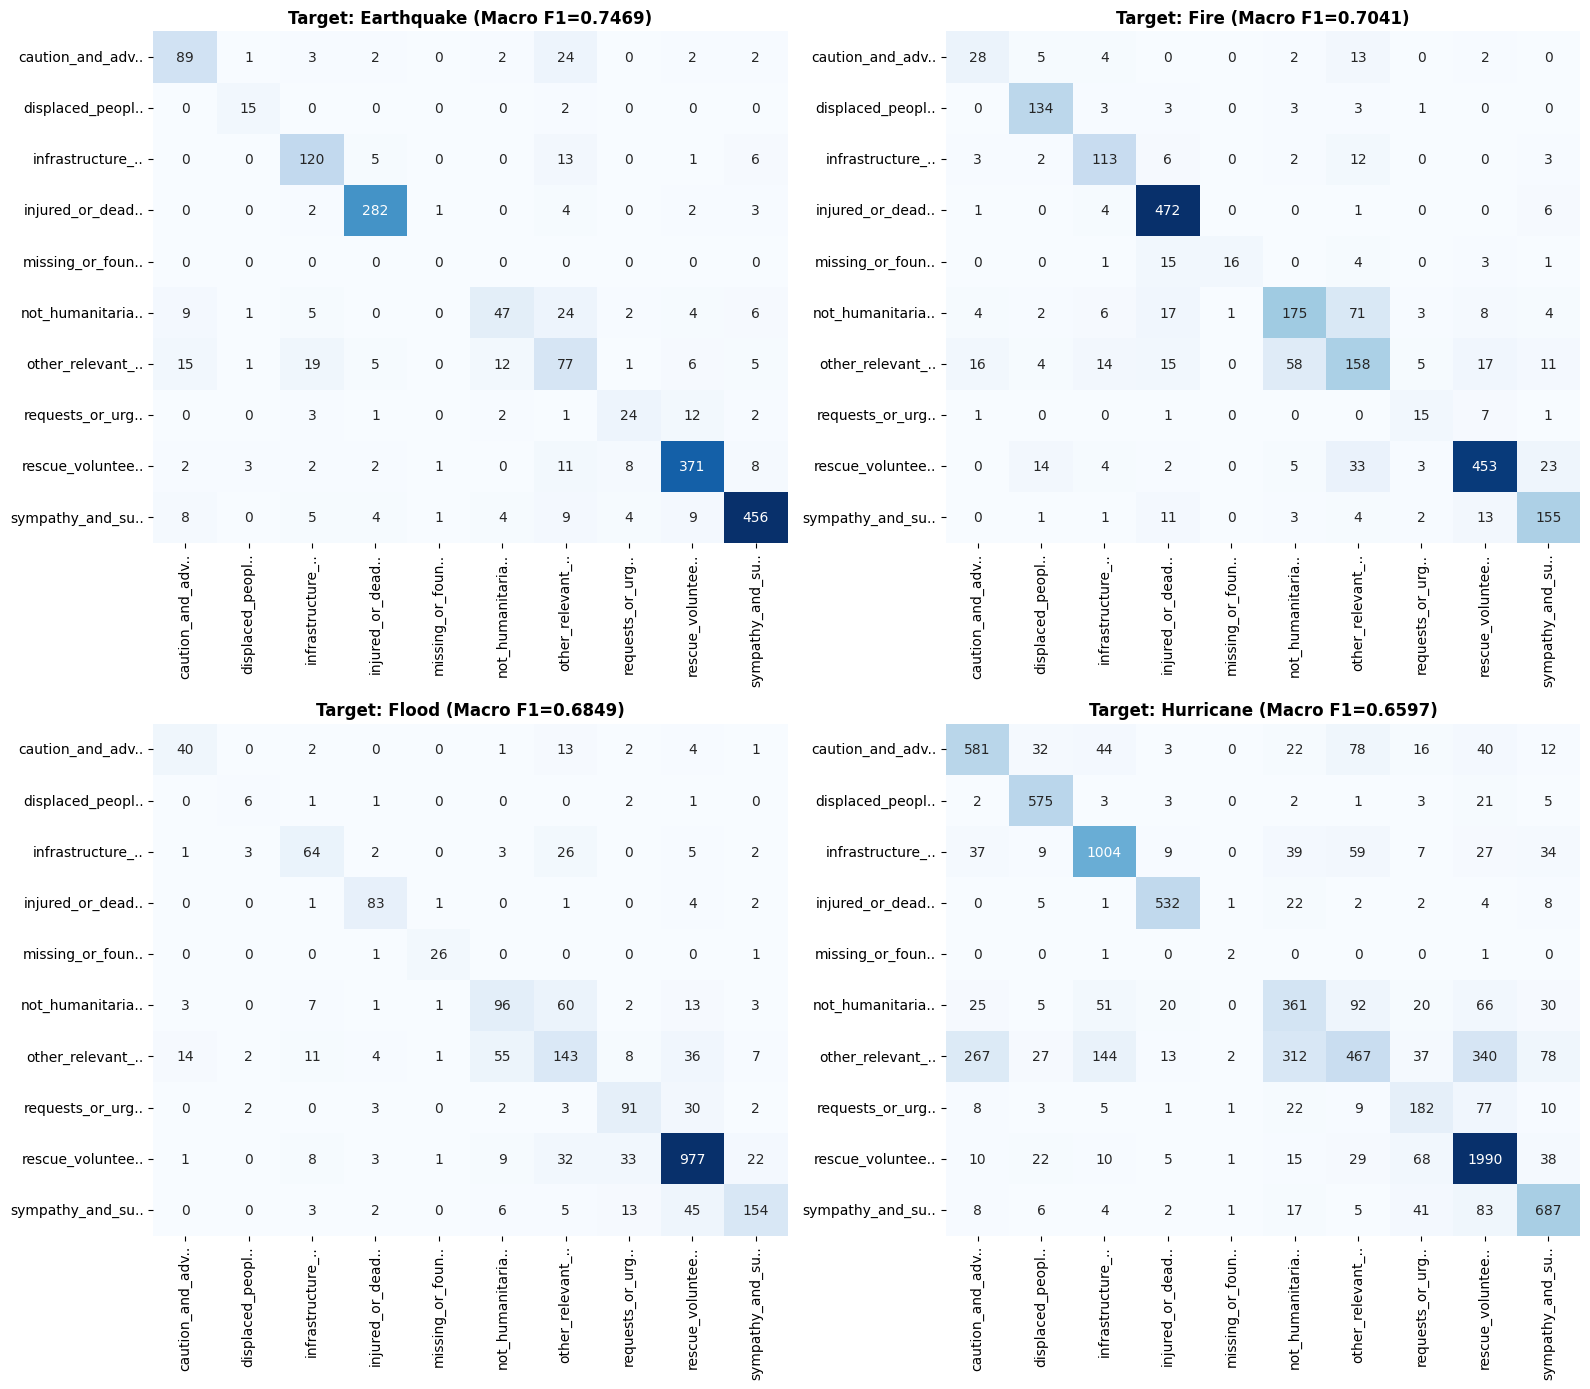

In [5]:
# ==========================================
# Section 4: Summary Report & Confusion Matrices
# ==========================================
res_df = pd.DataFrame(results)
print("\n" + "="*60)
print("LEAVE-ONE-TYPE-OUT FINAL EXPERIMENTAL REPORT")
print("="*60)
print(res_df[['Test_Disaster', 'Accuracy', 'F1_Macro', 'F1_Weighted']].to_string(index=False))
print("-" * 60)
print(f"Average Accuracy:    {res_df['Accuracy'].mean():.4f}")
print(f"Average F1 Macro:    {res_df['F1_Macro'].mean():.4f}")
print(f"Average F1 Weighted: {res_df['F1_Weighted'].mean():.4f}")
print("="*60)

# 1. Confusion Matrix Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
short_names = [n[:15] + '..' if len(n) > 15 else n for n in label_encoder.classes_]

for i, r in enumerate(results):
    cm = confusion_matrix(r['y_true'], r['y_preds'], labels=range(num_labels))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes.flatten()[i], 
                xticklabels=short_names, yticklabels=short_names, cbar=False)
    axes.flatten()[i].set_title(f"Target: {r['Test_Disaster']} (Macro F1={r['F1_Macro']:.4f})", fontweight='bold')

plt.tight_layout()
plt.show()

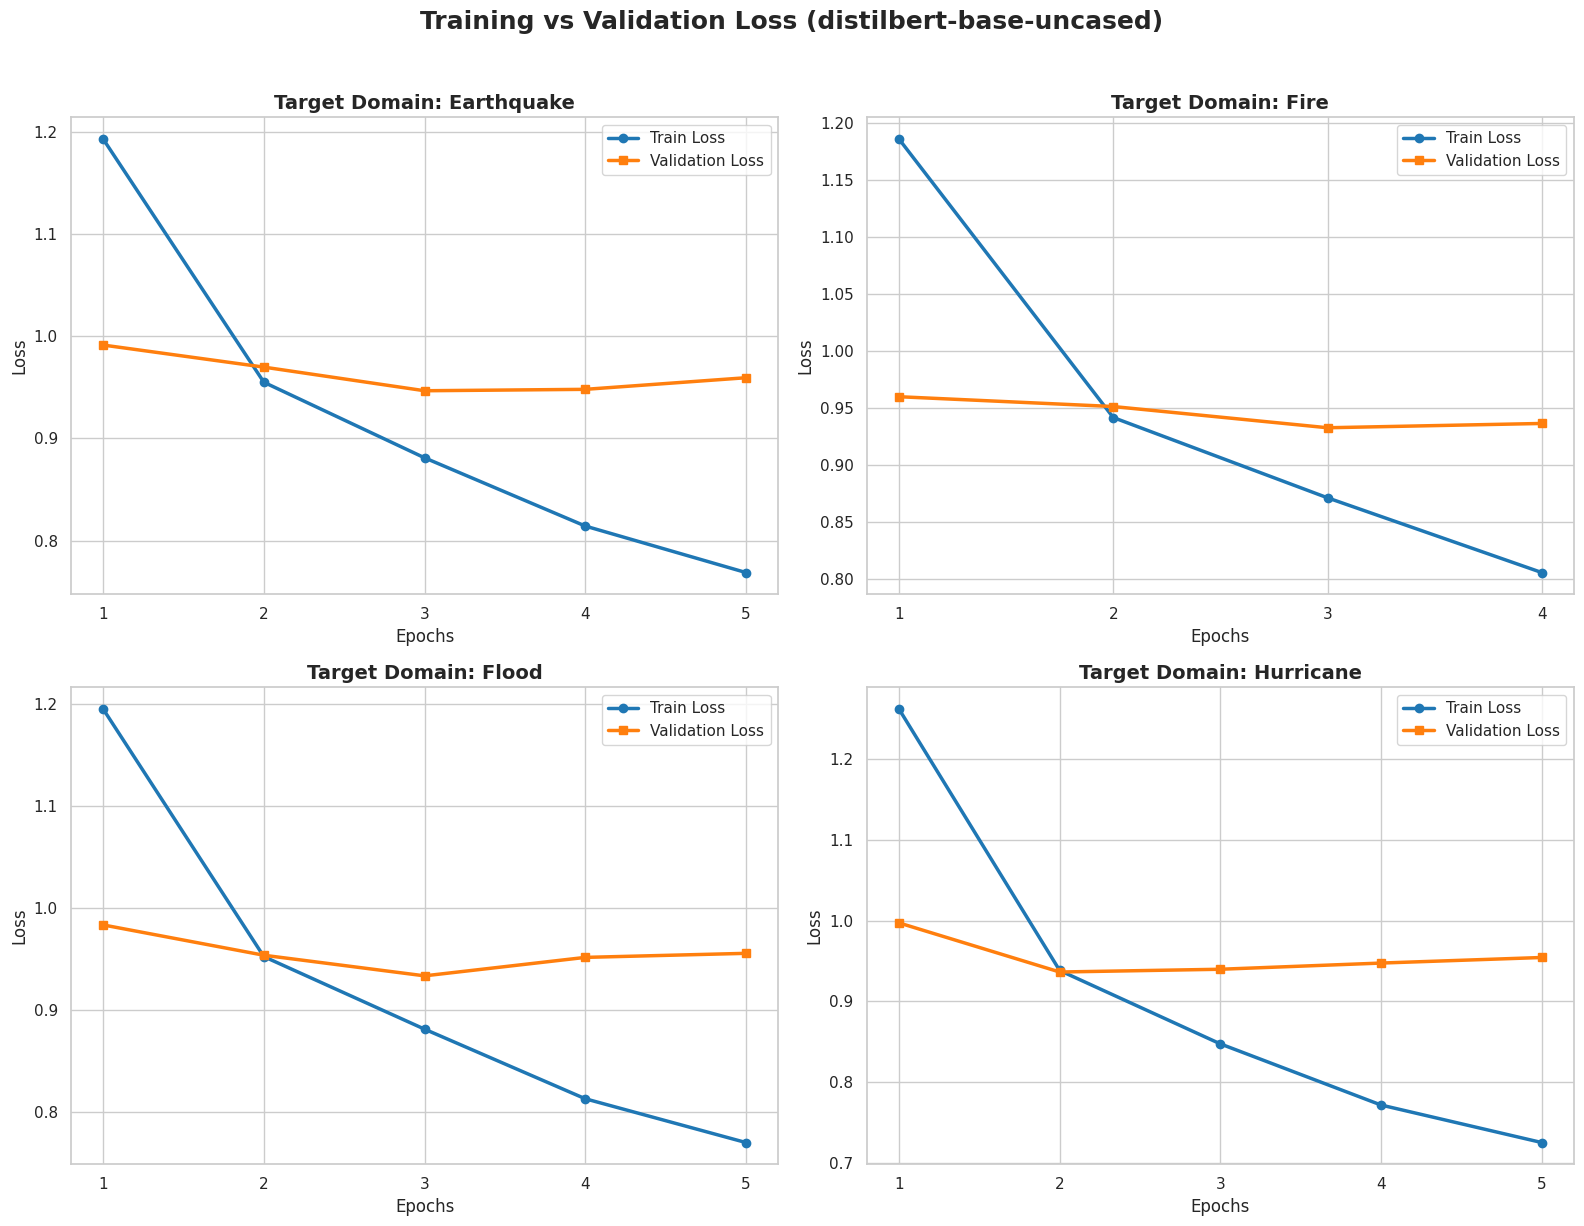

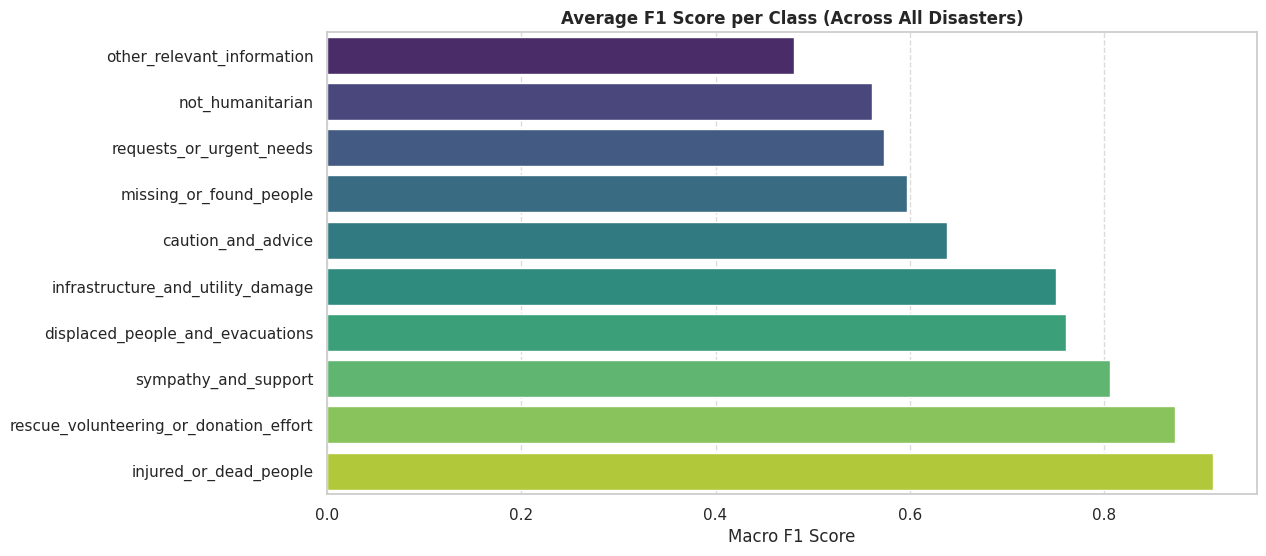


10 RANDOM CORRECT PREDICTIONS (Model Insights)


,Domain,Tweet Text,True Label,Predicted Label
0,Hurricane,here are legit fundraisers! donate here: do not go red cross!!,rescue_volunteering_or_donation_effort,rescue_volunteering_or_donation_effort
1,Fire,notley in fort mcmurray monday to survey wild disaster damage.,infrastructure_and_utility_damage,infrastructure_and_utility_damage
2,Hurricane,lend a helping hand to victims of disaster idai. we will be collecting donations from anywhere in harare in support of our brothers and sisters in need. contact us and well come to you! all proceeds go to chimanimani on wednesday 20 march. rt for awareness.,rescue_volunteering_or_donation_effort,rescue_volunteering_or_donation_effort
3,Flood,"kerala disaster s: 41 teams of ndrf are deployed in kerala to assist state administration in rescue, relief and rehabilitation work and to respond in any eventuality. today, ndrf teams deployed in districts idukki, kottayam and pathanamthtitta evacuated 122 persons to safer places",rescue_volunteering_or_donation_effort,rescue_volunteering_or_donation_effort
4,Fire,who wrote this. we know what trump thinks about the california disaster s and none of us will forgive him the earlier tweet,not_humanitarian,not_humanitarian
5,Hurricane,*update* also needed: - diapers - hygiene items - contractor sized trash bags - gallon ziplock bags accepted at any fc dfw location.,requests_or_urgent_needs,requests_or_urgent_needs
6,Hurricane,richard bransons home is just a shell after disaster irma destroyed everything via,infrastructure_and_utility_damage,infrastructure_and_utility_damage
7,Flood,kerala disaster s2018 oprahat relief material & fresh water being embarked on board ship which is sailing out to kochi for kerala disaster relief operations,rescue_volunteering_or_donation_effort,rescue_volunteering_or_donation_effort
8,Hurricane,we are so happy to report that the buccaneer has been spared of major damage after disaster maria passed by st.,infrastructure_and_utility_damage,infrastructure_and_utility_damage
9,Flood,"on my company email, the organizations listed for nebraska are: and there is a phone number for the nebraska cattlemen disaster relief fund: 402-475-233",rescue_volunteering_or_donation_effort,rescue_volunteering_or_donation_effort



10 RANDOM INCORRECT PREDICTIONS (Error Analysis)


,Domain,Tweet Text,True Label,Predicted Label
0,Flood,kerala disaster s: uae envoy dr ahmed albanna said they will stand and they will do whatever they can do for their friends in disaster -hit kerala. itvideo keralasos watch more videos:,other_relevant_information,sympathy_and_support
1,Flood,people of kerla need our help. i request you to everyone should not only help human being but also animals. kerla needs our support for human being and animals required. visit site for more information: kerala disaster s kerala disaster s2018,sympathy_and_support,requests_or_urgent_needs
2,Fire,rt : wild disaster information alert issued for little smoky area residents. an evacuation notice has not been issued.,caution_and_advice,displaced_people_and_evacuations
3,Hurricane,wonderful thread about why the red cross sucks ass,not_humanitarian,rescue_volunteering_or_donation_effort
4,Flood,why? is this because we are too proud to take aid from uae? or else the govt. cannot charged gst on it. its got to be either way. think about it. kerala disaster s kerala disaster relief,rescue_volunteering_or_donation_effort,other_relevant_information
5,Fire,burning blues for wild disaster victims may 22 4pm $10 for ymm disaster red,rescue_volunteering_or_donation_effort,other_relevant_information
6,Hurricane,"roads in boulevard oaks, houston were still too deep to drive through sunday. photo courtesy of brenda riley. disaster harvey",not_humanitarian,infrastructure_and_utility_damage
7,Hurricane,fear of casualties are being reported in abaco – marsh harbour under water via dorian,other_relevant_information,injured_or_dead_people
8,Hurricane,. on periscope: dumpster diving for watermelon-houston disaster ing harvey,not_humanitarian,other_relevant_information
9,Hurricane,the disaster ὠf the disaster isuponus,not_humanitarian,caution_and_advice


In [6]:
# ==========================================
# Section 5: Error Analysis & Insights Visualization
# ==========================================

# 1. Plotting Learning Curves (Loss)
sns.set_theme(style="whitegrid")
fig_loss, axes_loss = plt.subplots(2, 2, figsize=(16, 12))
fig_loss.suptitle(f'Training vs Validation Loss ({MODEL_NAME})', fontsize=18, fontweight='bold', y=1.02)

for i, res in enumerate(results):
    ax = axes_loss.flatten()[i]
    history = res['history']
    epochs = range(1, len(history['t_loss']) + 1)
    ax.plot(epochs, history['t_loss'], label='Train Loss', marker='o', linewidth=2.5, color='#1f77b4')
    ax.plot(epochs, history['v_loss'], label='Validation Loss', marker='s', linewidth=2.5, color='#ff7f0e')
    ax.set_title(f"Target Domain: {res['Test_Disaster']}", fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_xticks(epochs)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# 2. Plot Average Class-wise F1 Scores across all Domains
class_f1_scores = {c: [] for c in label_encoder.classes_}

for res in results:
    # Compute F1 for all classes. Missing classes in a test set will yield 0.0 (ignored in valid mean later)
    f1_per_class = f1_score(res['y_true'], res['y_preds'], average=None, labels=range(num_labels), zero_division=0)
    present_labels = np.unique(res['y_true'])
    
    for i, c in enumerate(label_encoder.classes_):
        # Only append F1 score if the class was actually present in the test set
        if i in present_labels:
            class_f1_scores[c].append(f1_per_class[i])

# Calculate valid average
avg_class_f1 = {c: np.mean(scores) if len(scores) > 0 else 0.0 for c, scores in class_f1_scores.items()}

plt.figure(figsize=(12, 6))
class_df = pd.DataFrame(list(avg_class_f1.items()), columns=['Class', 'Average F1']).sort_values(by='Average F1', ascending=True)
sns.barplot(x='Average F1', y='Class', data=class_df, palette='viridis')
plt.title("Average F1 Score per Class (Across All Disasters)", fontweight='bold')
plt.xlabel("Macro F1 Score")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


# 3. Qualitative Error Analysis: Random Correct & Incorrect Predictions
all_texts, all_trues, all_preds, all_domains = [], [], [], []

for res in results:
    all_texts.extend(res['test_texts'])
    all_trues.extend(res['y_true'])
    all_preds.extend(res['y_preds'])
    all_domains.extend([res['Test_Disaster']] * len(res['test_texts']))

analysis_df = pd.DataFrame({
    'Domain': all_domains,
    'Tweet Text': all_texts,
    'True Label': label_encoder.inverse_transform(all_trues),
    'Predicted Label': label_encoder.inverse_transform(all_preds)
})

correct_df = analysis_df[analysis_df['True Label'] == analysis_df['Predicted Label']]
incorrect_df = analysis_df[analysis_df['True Label'] != analysis_df['Predicted Label']]

print("\n" + "="*80)
print("10 RANDOM CORRECT PREDICTIONS (Model Insights)")
print("="*80)
# Set pandas option to show full text
pd.set_option('display.max_colwidth', None)
display(correct_df.sample(min(10, len(correct_df)), random_state=42).reset_index(drop=True))

print("\n" + "="*80)
print("10 RANDOM INCORRECT PREDICTIONS (Error Analysis)")
print("="*80)
display(incorrect_df.sample(min(10, len(incorrect_df)), random_state=42).reset_index(drop=True))
pd.reset_option('display.max_colwidth') # reset option